# Basic analytical simulation example
- Generate a typical scintillation detector stack
- Generate a GOES class flare across a wide energy range
- Generate the transmission curve for the detection stack, and apply it to the flare.
- TODO energy resolution

In [1]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.visualization import quantity_support

from adetsim import detection, flares, matter

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
# Define the materials present in the detector chain
thin_foil = matter.Material(
    name="aluminum filter",
    thickness=(100 << u.um),
    density=(2.7 << u.g / u.cm**3),
    attenuations=matter.Attenuations.from_element("Al"),
    average_across_bins=False
)

delrin = matter.Material(
    name="delrin enclosure",
    thickness=(3.2 << u.mm),
    density=(1.41 << u.g / u.cm**3),
    attenuations=matter.Attenuations.from_compound_dict({"C": 1, "H": 1, "O": 2}),
    average_across_bins=False
)

ptfe = matter.Material(
    name="ptfe reflector",
    thickness=(750 << u.um),
    density=(2.14 << u.g / u.cm**3),
    attenuations=matter.Attenuations.from_compound_dict({"C": 1, "F": 2}),
    average_across_bins=False
)

yap = matter.Material(
    name="yap scintillator",
    thickness=(4 << u.mm),
    density=(5.4 << u.g / u.cm**3),
    attenuations=matter.Attenuations.from_compound_dict({"Y": 1, "Al": 1, "O": 3}),
    average_across_bins=False
)

In [3]:
# The last element is the detection element.
yap_stack = detection.PhysicalDetectorStack([thin_foil, delrin, ptfe, yap])

# Turn on the physics we want to use
for mat in yap_stack.materials:
    mat.attenuations.photoelectric = True
    mat.attenuations.rayleigh = True
    mat.attenuations.compton = False

In [4]:
# Define the flare that we're observing

goes_class = "M5"
start, end = 2, 300
edges = np.geomspace(start, end, num=500) << u.keV

flare = flares.Flare(goes_class=goes_class, energy_edges=edges)

# Determine the detected flux
detected = yap_stack.compute_absorption(edges)

/home/william/dev/analytical-detector-sim/.venv/lib/python3.14/site-packages/sunkit_spex/legacy/thermal.py:763: UserWarning: Some input energy values outside valid range of 1.0002920302956426--200.15819869050395 keV. Flux will be zero outside this range.
  warnings.warn(message)


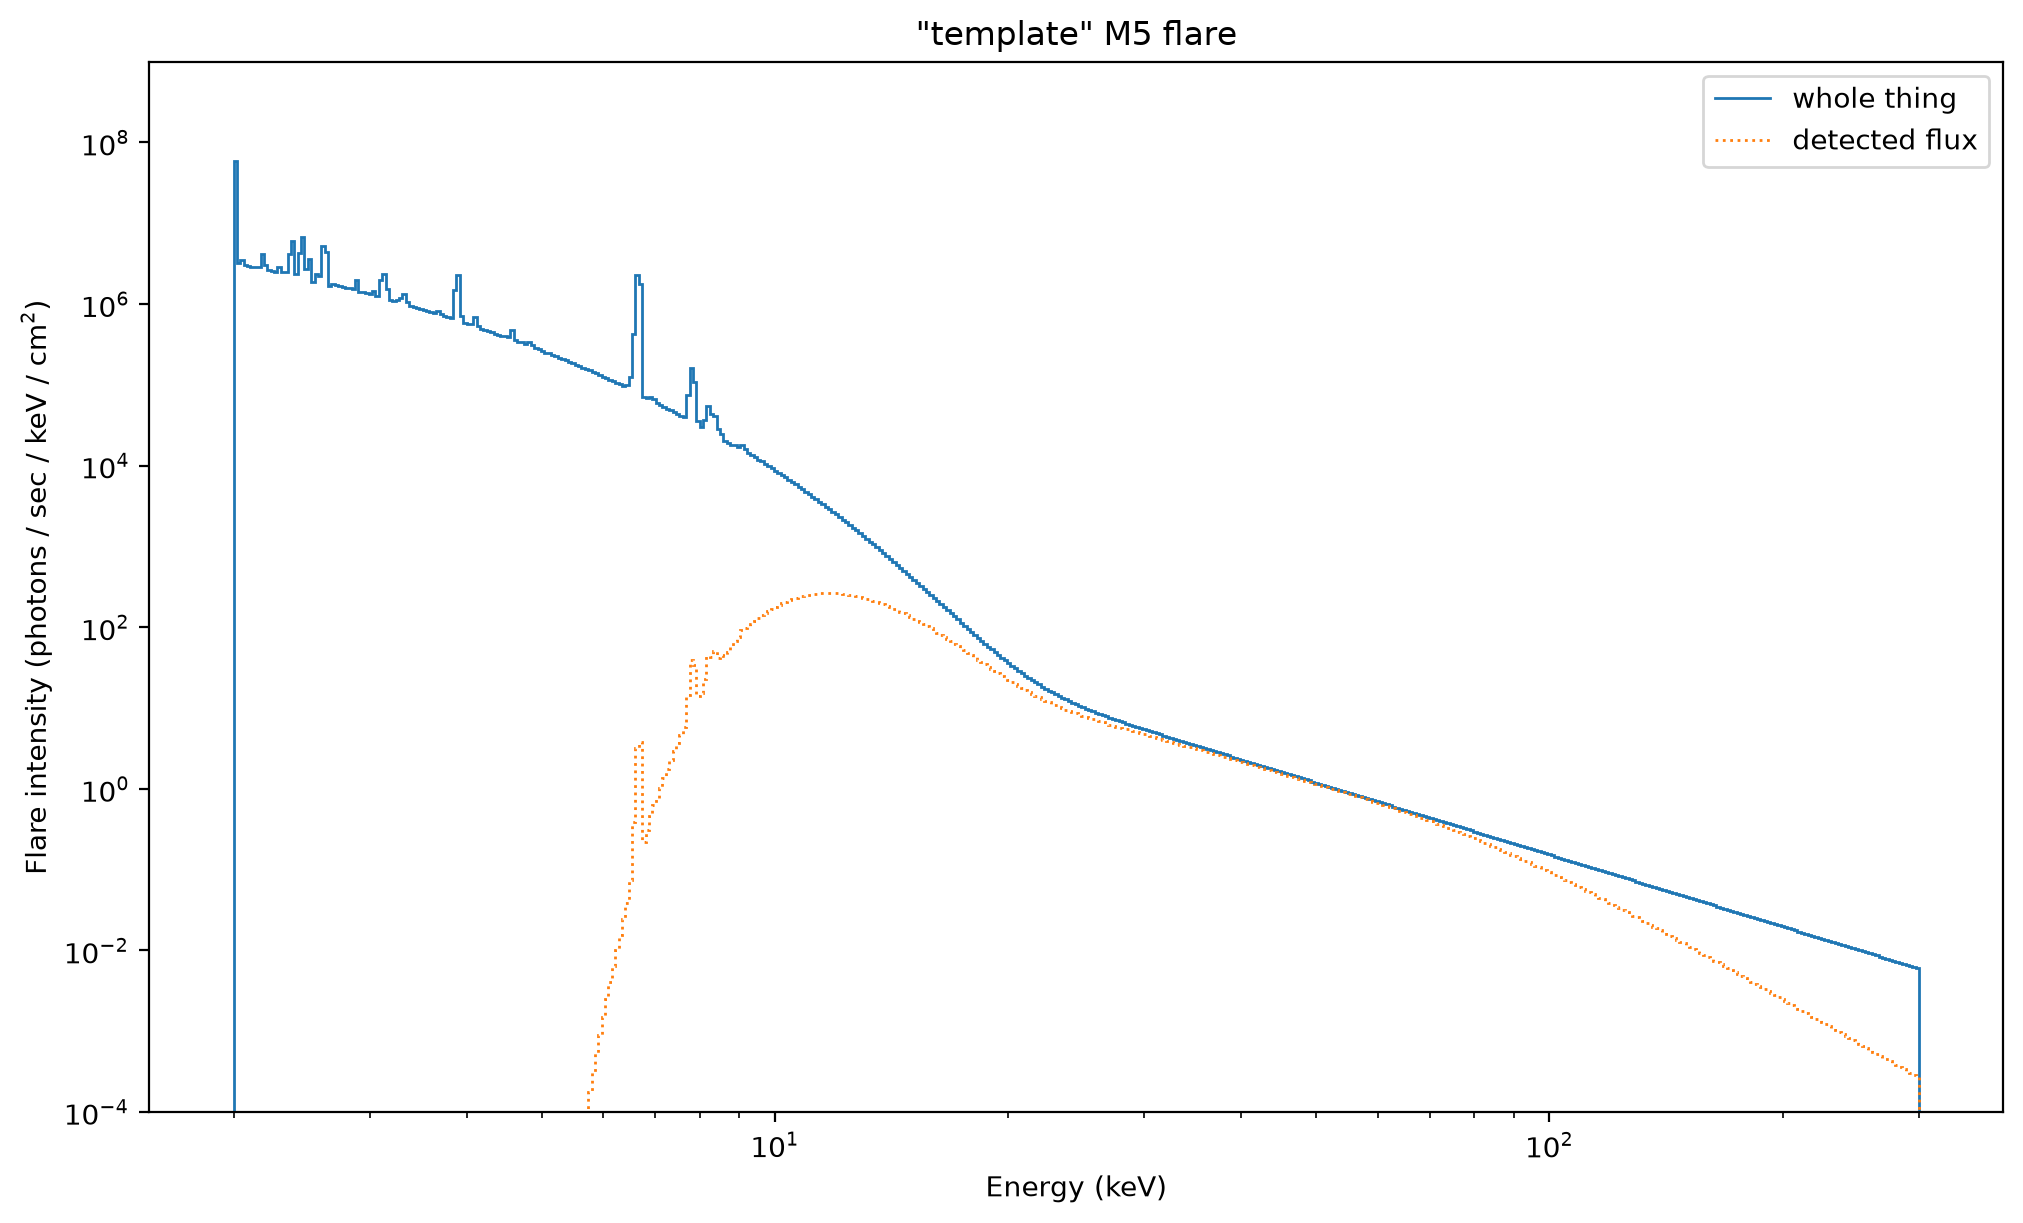

In [5]:
fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")

with quantity_support():
    ax.stairs(flare.all_emission, flare.energy_edges, label="whole thing")
    ax.stairs(
        detected * flare.all_emission,
        flare.energy_edges,
        label="detected flux",
        ls="dotted",
    )

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Flare intensity (photons / sec / keV / cm${}^2$)")
ax.set_title(f'"template" {goes_class} flare')

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylim(1e-4, 1e9)
ax.legend()

plt.show()

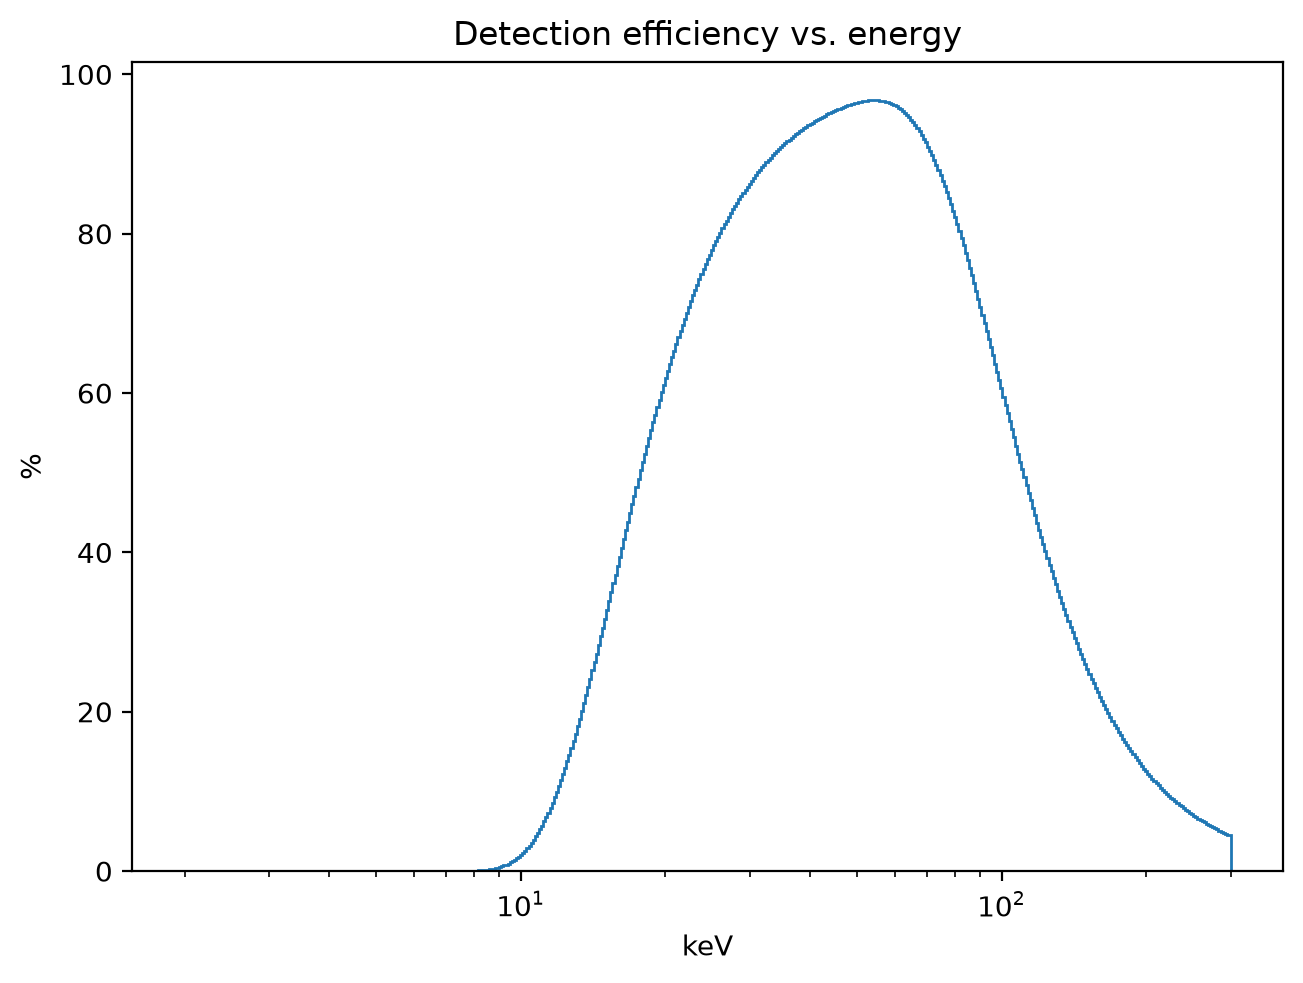

In [6]:
fig, ax = plt.subplots(layout="constrained")
with quantity_support():
    ax.stairs(detected * (100 << u.percent), edges)
ax.set(xscale="log", yscale="linear", title="Detection efficiency vs. energy")
plt.show()